In [1]:
import os
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import Markdown, display

# Task 3 — Customer Engagement Analysis

This standalone notebook answers the six Task 3 objectives in the official brief for calendar year 2025. It describes engagement scores, channel adoption, online-spend share, category diversity, transaction frequency and recency, and the financially healthy but less-engaged crossover. The source is synthetic; results are analytical descriptions, not evidence of causality, retention, churn, contactability, or creditworthiness.

## 1. Paths, sources, and metric contract

The notebook must run with `code/` as its working directory unless `BI_PROJECT_ROOT` explicitly identifies the repository root. `BI_DATA_DIR` overrides the input directory. `BI_OUTPUT_DIR` overrides the artifact root, under which this notebook writes only `image/task3/`. Missing input or an unwritable output directory is a hard error; no substitute or fabricated data are used.

In [2]:
working_directory = Path.cwd().resolve()
project_root_override = os.environ.get("BI_PROJECT_ROOT")
if project_root_override:
    PROJECT_ROOT = Path(project_root_override).expanduser().resolve()
elif working_directory.name == "code":
    PROJECT_ROOT = working_directory.parent
else:
    raise RuntimeError(
        "Run this notebook with the repository's code/ directory as the working directory, "
        "or set BI_PROJECT_ROOT to the repository root."
    )

if not (PROJECT_ROOT / "code").is_dir():
    raise RuntimeError(f"Resolved project root does not contain code/: {PROJECT_ROOT}")

DATA_DIR = Path(os.environ.get("BI_DATA_DIR", PROJECT_ROOT / "data")).expanduser().resolve()
OUTPUT_ROOT = Path(os.environ.get("BI_OUTPUT_DIR", PROJECT_ROOT)).expanduser().resolve()
FIGURE_DIR = OUTPUT_ROOT / "image" / "task3"
MONTHLY_PATH = DATA_DIR / "consumer_financial_health_engagement_2025.csv"
TRANSACTION_PATH = DATA_DIR / "consumer_transactions_2025.csv"

missing_inputs = [str(path) for path in (MONTHLY_PATH, TRANSACTION_PATH) if not path.is_file()]
if missing_inputs:
    raise FileNotFoundError("Required input file(s) not found: " + ", ".join(missing_inputs))

try:
    FIGURE_DIR.mkdir(parents=True, exist_ok=True)
    write_probe = FIGURE_DIR / ".bi_write_probe"
    write_probe.write_text("ok", encoding="utf-8")
    write_probe.unlink()
except OSError as exc:
    raise RuntimeError(f"Task 3 figure directory is not writable: {FIGURE_DIR}") from exc

sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.max_rows", 30)
pd.set_option("display.max_columns", 30)

def save_show_close(figure, filename, source_caption):
    output_path = FIGURE_DIR / filename
    figure.text(
        0.01, 0.01, source_caption,
        ha="left", va="bottom", fontsize=8, color="#4a4a4a", linespacing=1.25,
    )
    try:
        figure.tight_layout(rect=(0, 0.13, 1, 0.94))
        figure.savefig(output_path, dpi=160, bbox_inches="tight")
    except OSError as exc:
        plt.close(figure)
        raise RuntimeError(f"Could not save figure to {output_path}") from exc
    plt.show()
    plt.close(figure)
    return output_path

print(f"Monthly source: {MONTHLY_PATH}")
print(f"Transaction source: {TRANSACTION_PATH}")
print(f"Task 3 figures: {FIGURE_DIR}")

Monthly source: /home/pearspringmind/Studying/BI-UEL/data/consumer_financial_health_engagement_2025.csv
Transaction source: /home/pearspringmind/Studying/BI-UEL/data/consumer_transactions_2025.csv
Task 3 figures: /home/pearspringmind/Studying/BI-UEL/image/task3


### Grain and denominators

| Measure | Numerator | Denominator | Grain and window |
|---|---|---|---|
| Engagement-band share | Customer-month rows in the band | All observed customer-month rows | Consumer-month, Jan–Dec 2025 |
| Customers ever observed in a band | Distinct consumers with at least one month in the band | All distinct observed consumers | Consumer over observed 2025 history; band memberships can overlap |
| Channel transaction share | Transactions through the channel | All streamed 2025 transactions | Transaction |
| Channel VND share | VND through the channel | VND across all streamed 2025 transactions | Transaction |
| Channel adoption | Distinct consumers using the channel | All distinct consumers in the monthly table | Distinct consumer, observed 2025 history |
| Average online-spend share | Mean of each row's `online_spend_ratio` | Observed customer-month rows | Unweighted consumer-month average |
| Aggregate online-spend share | Sum of `online_spend_vnd` | Sum of `total_spend_vnd` | VND-weighted across all observed customer-months |
| Crossover | `financial_health_score >= 80` and engagement below stated cutoff | Reported against all rows/customers and healthy rows as labeled | Consumer-month, distinct 2025 consumer, and December snapshot |

“Online” always means `online_transaction_flag == 1` or the monthly online fields. “Digital channel” means a non-POS channel and includes QR Payment even when its online flag is zero. The two concepts are not interchangeable.

## 2. Load and validate the consumer-month table

In [3]:
monthly_columns = [
    "consumer_id", "analysis_month", "age", "gender", "occupation",
    "province_city", "monthly_income_vnd", "total_spend_vnd",
    "online_spend_vnd", "transaction_count", "category_diversity",
    "online_spend_ratio", "transaction_recency_days", "engagement_score",
    "financial_health_score", "engagement_segment",
]
try:
    monthly = pd.read_csv(
        MONTHLY_PATH,
        usecols=monthly_columns,
        dtype={
            "consumer_id": "string",
            "gender": "string",
            "occupation": "string",
            "province_city": "string",
            "engagement_segment": "string",
        },
        parse_dates=["analysis_month"],
    )
except (OSError, ValueError, pd.errors.ParserError) as exc:
    raise RuntimeError(f"Could not load the required monthly table: {MONTHLY_PATH}") from exc

if monthly.empty:
    raise ValueError("The monthly table is empty.")
if monthly[monthly_columns].isna().any().any():
    missing_counts = monthly[monthly_columns].isna().sum()
    raise ValueError("Unexpected missing monthly values: " + str(missing_counts[missing_counts > 0].to_dict()))
if monthly.duplicated(["consumer_id", "analysis_month"]).any():
    raise ValueError("The monthly table contains duplicate consumer-month keys.")
if not monthly["analysis_month"].dt.year.eq(2025).all():
    raise ValueError("The monthly table contains observations outside calendar year 2025.")
if not monthly["analysis_month"].dt.day.eq(1).all():
    raise ValueError("analysis_month must be normalized to the first day of each month.")
if not monthly["engagement_score"].between(0, 100).all():
    raise ValueError("engagement_score must be between 0 and 100.")
if not monthly["financial_health_score"].between(0, 100).all():
    raise ValueError("financial_health_score must be between 0 and 100.")
if not monthly["online_spend_ratio"].between(0, 1).all():
    raise ValueError("online_spend_ratio must be between 0 and 1.")
nonnegative_columns = [
    "monthly_income_vnd", "total_spend_vnd", "online_spend_vnd",
    "transaction_count", "category_diversity", "transaction_recency_days",
]
if monthly[nonnegative_columns].lt(0).any().any():
    raise ValueError("Monthly count, spend, income, diversity, and recency fields must be nonnegative.")
if len(monthly) != 10_992 or monthly["consumer_id"].nunique() != 999:
    raise ValueError(
        f"Expected 10,992 consumer-month rows and 999 consumers; found {len(monthly):,} rows "
        f"and {monthly['consumer_id'].nunique():,} consumers."
    )

segment_translation = {
    "Tương tác thấp": "Low",
    "Tương tác trung bình": "Medium",
    "Tương tác cao": "High",
    "Tương tác rất cao": "Very high",
}
segment_order = ["Low", "Medium", "High", "Very high"]
monthly["engagement_band"] = monthly["engagement_segment"].map(segment_translation)
if monthly["engagement_band"].isna().any():
    unknown_segments = sorted(monthly.loc[monthly["engagement_band"].isna(), "engagement_segment"].unique())
    raise ValueError(f"Unknown engagement segment label(s): {unknown_segments}")
expected_band = pd.cut(
    monthly["engagement_score"],
    bins=[-np.inf, 40, 60, 80, np.inf],
    labels=segment_order,
    right=False,
).astype("string")
if not expected_band.eq(monthly["engagement_band"]).all():
    mismatch_count = int((expected_band != monthly["engagement_band"]).sum())
    raise ValueError(f"{mismatch_count:,} rows disagree with the documented engagement-band thresholds.")
monthly["engagement_band"] = pd.Categorical(
    monthly["engagement_band"], categories=segment_order, ordered=True
)

monthly_summary = pd.Series({
    "customer_month_rows": len(monthly),
    "distinct_consumers": monthly["consumer_id"].nunique(),
    "first_month": monthly["analysis_month"].min().date(),
    "last_month": monthly["analysis_month"].max().date(),
    "median_observed_months_per_consumer": monthly.groupby("consumer_id").size().median(),
})
display(monthly_summary.to_frame("value"))

,value
customer_month_rows,10992
distinct_consumers,999
first_month,2025-01-01
last_month,2025-12-01
median_observed_months_per_consumer,12.0


## 3. Engagement score distribution and official bands

The official score bands are Low (`<40`), Medium (`40–<60`), High (`60–<80`), and Very high (`>=80`). Customer-month shares describe the row-level distribution. The customer view counts whether a consumer appeared in a band at least once during observed 2025 history; because a consumer can move between bands, those customer shares may overlap and need not sum to 100%.

In [4]:
total_customer_months = len(monthly)
total_consumers = monthly["consumer_id"].nunique()
band_month_counts = monthly["engagement_band"].value_counts(sort=False).reindex(segment_order, fill_value=0)
band_customer_counts = (
    monthly.groupby("engagement_band", observed=False)["consumer_id"]
    .nunique()
    .reindex(segment_order, fill_value=0)
)
engagement_band_table = pd.DataFrame({
    "customer_months": band_month_counts.astype(int),
    "customer_month_share_pct": (100 * band_month_counts / total_customer_months).round(2),
    "customers_with_any_month": band_customer_counts.astype(int),
    "customer_any_month_share_pct": (100 * band_customer_counts / total_consumers).round(2),
})
display(engagement_band_table)
display(monthly["engagement_score"].describe(percentiles=[0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99]).to_frame())

,customer_months,customer_month_share_pct,customers_with_any_month,customer_any_month_share_pct
engagement_band,,,,
Low,10,0.09,10,1.00
Medium,100,0.91,97,9.71
High,7058,64.21,894,89.49
Very high,3824,34.79,889,88.99


,engagement_score
count,10992.000000
mean,77.819314
std,6.326936
min,9.700000
1%,60.082000
5%,67.700000
25%,74.800000
50%,78.100000
75%,81.400000
95%,87.200000


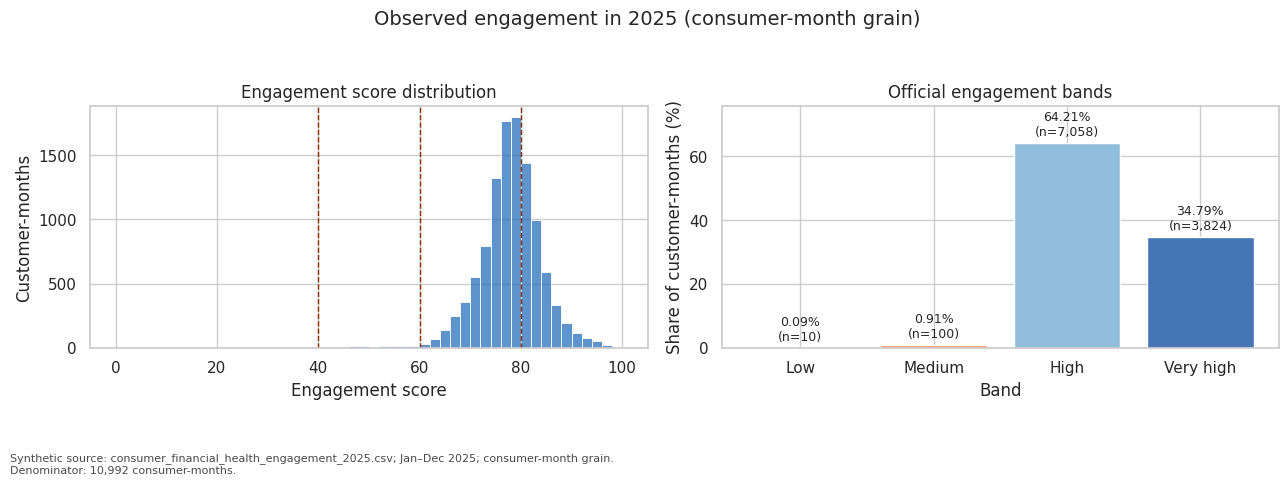

Saved: /home/pearspringmind/Studying/BI-UEL/image/task3/01_engagement_distribution.png


In [5]:
figure, axes = plt.subplots(1, 2, figsize=(13, 4.8))
sns.histplot(
    data=monthly, x="engagement_score", bins=np.arange(0, 102, 2),
    color="#2a6fbb", edgecolor="white", ax=axes[0],
)
for boundary in (40, 60, 80):
    axes[0].axvline(boundary, color="#8c2d04", linestyle="--", linewidth=1)
axes[0].set(title="Engagement score distribution", xlabel="Engagement score", ylabel="Customer-months")

band_colors = ["#d73027", "#fc8d59", "#91bfdb", "#4575b4"]
bars = axes[1].bar(
    engagement_band_table.index,
    engagement_band_table["customer_month_share_pct"],
    color=band_colors,
)
axes[1].bar_label(
    bars,
    labels=[f"{value:.2f}%\n(n={count:,})" for value, count in zip(
        engagement_band_table["customer_month_share_pct"],
        engagement_band_table["customer_months"],
    )],
    padding=3, fontsize=9,
)
axes[1].set(title="Official engagement bands", xlabel="Band", ylabel="Share of customer-months (%)")
axes[1].set_ylim(0, max(5, engagement_band_table["customer_month_share_pct"].max() * 1.18))
figure.suptitle("Observed engagement in 2025 (consumer-month grain)", fontsize=14)
engagement_distribution_path = save_show_close(
    figure,
    "01_engagement_distribution.png",
    "Synthetic source: consumer_financial_health_engagement_2025.csv; Jan–Dec 2025; consumer-month grain.\n"
    f"Denominator: {len(monthly):,} consumer-months.",
)
print(f"Saved: {engagement_distribution_path}")

**Interpretation.** The histogram exposes the score's shape and any concentration near the upper end; dashed lines are the documented band boundaries. The adjacent bars give exact shares of the **10,992 observed customer-months**, not mutually exclusive lifetime customer types. A ceiling-heavy score should be read as limited separation within this synthetic scoring system—not proof that customers are retained, satisfied, or financially healthy.

## 4. Stream the transaction table and measure five channels

Only five required columns are read in bounded chunks. No cell loads or copies the full transaction table. The scan accumulates compact channel totals and sets of distinct consumer IDs.

In [6]:
channel_order = ["POS", "QR Payment", "E-commerce", "Mobile App", "Recurring Payment"]
transaction_usecols = [
    "consumer_id", "transaction_channel", "spend_amount_vnd",
    "online_transaction_flag", "transaction_month",
]
chunk_size = 200_000
channel_transaction_counts = pd.Series(0, index=channel_order, dtype="int64")
channel_spend_vnd = pd.Series(0, index=channel_order, dtype="int64")
channel_adopters = {channel: set() for channel in channel_order}
transaction_consumer_ids = set()
digital_consumer_ids = set()
online_consumer_ids = set()
transaction_row_count = 0
transaction_total_spend_vnd = 0
online_transaction_count = 0
online_transaction_spend_vnd = 0
qr_offline_transaction_count = 0

try:
    transaction_chunks = pd.read_csv(
        TRANSACTION_PATH,
        usecols=transaction_usecols,
        dtype={
            "consumer_id": "string",
            "transaction_channel": "string",
            "spend_amount_vnd": "int64",
            "online_transaction_flag": "int8",
            "transaction_month": "int8",
        },
        chunksize=chunk_size,
    )
    for chunk_number, transaction_chunk in enumerate(transaction_chunks, start=1):
        if transaction_chunk[transaction_usecols].isna().any().any():
            raise ValueError(f"Missing required transaction value in chunk {chunk_number}.")
        unknown_channels = sorted(set(transaction_chunk["transaction_channel"].unique()) - set(channel_order))
        if unknown_channels:
            raise ValueError(f"Unknown transaction channel(s) in chunk {chunk_number}: {unknown_channels}")
        if transaction_chunk["spend_amount_vnd"].lt(0).any():
            raise ValueError(f"Negative transaction amount in chunk {chunk_number}.")
        if not transaction_chunk["online_transaction_flag"].isin([0, 1]).all():
            raise ValueError(f"Invalid online flag in chunk {chunk_number}.")
        if not transaction_chunk["transaction_month"].between(1, 12).all():
            raise ValueError(f"Invalid transaction month in chunk {chunk_number}.")

        chunk_counts = transaction_chunk["transaction_channel"].value_counts()
        chunk_spend = transaction_chunk.groupby("transaction_channel")["spend_amount_vnd"].sum()
        channel_transaction_counts = channel_transaction_counts.add(chunk_counts, fill_value=0).astype("int64")
        channel_spend_vnd = channel_spend_vnd.add(chunk_spend, fill_value=0).astype("int64")

        for channel in channel_order:
            channel_adopters[channel].update(
                transaction_chunk.loc[transaction_chunk["transaction_channel"].eq(channel), "consumer_id"].tolist()
            )
        transaction_consumer_ids.update(transaction_chunk["consumer_id"].tolist())
        digital_mask = transaction_chunk["transaction_channel"].ne("POS")
        online_mask = transaction_chunk["online_transaction_flag"].eq(1)
        qr_offline_mask = transaction_chunk["transaction_channel"].eq("QR Payment") & ~online_mask
        digital_consumer_ids.update(transaction_chunk.loc[digital_mask, "consumer_id"].tolist())
        online_consumer_ids.update(transaction_chunk.loc[online_mask, "consumer_id"].tolist())
        transaction_row_count += len(transaction_chunk)
        transaction_total_spend_vnd += int(transaction_chunk["spend_amount_vnd"].sum())
        online_transaction_count += int(online_mask.sum())
        online_transaction_spend_vnd += int(transaction_chunk.loc[online_mask, "spend_amount_vnd"].sum())
        qr_offline_transaction_count += int(qr_offline_mask.sum())
except (OSError, ValueError, pd.errors.ParserError) as exc:
    raise RuntimeError(f"Bounded transaction scan failed for {TRANSACTION_PATH}: {exc}") from exc

if transaction_row_count != 1_852_394:
    raise ValueError(f"Expected 1,852,394 transactions; streamed {transaction_row_count:,}.")
if int(channel_transaction_counts.sum()) != transaction_row_count:
    raise ValueError("Five-channel transaction counts do not reconcile to the streamed row count.")
if int(channel_spend_vnd.sum()) != transaction_total_spend_vnd:
    raise ValueError("Five-channel VND totals do not reconcile to total streamed spend.")
monthly_consumer_ids = set(monthly["consumer_id"].tolist())
unmatched_transaction_consumers = transaction_consumer_ids - monthly_consumer_ids
if unmatched_transaction_consumers:
    raise ValueError(
        f"Found {len(unmatched_transaction_consumers):,} transaction consumers absent from the monthly table."
    )
if transaction_consumer_ids != monthly_consumer_ids:
    raise ValueError("Transaction and monthly sources do not contain the same distinct consumer population.")

channel_table = pd.DataFrame({
    "transaction_count": channel_transaction_counts,
    "transaction_share_pct": 100 * channel_transaction_counts / transaction_row_count,
    "spend_vnd": channel_spend_vnd,
    "vnd_share_pct": 100 * channel_spend_vnd / transaction_total_spend_vnd,
    "distinct_adopters": [len(channel_adopters[channel]) for channel in channel_order],
    "adoption_share_pct": [100 * len(channel_adopters[channel]) / total_consumers for channel in channel_order],
}, index=channel_order)
channel_table.index.name = "channel"
channel_display = channel_table.copy()
for percentage_column in ["transaction_share_pct", "vnd_share_pct", "adoption_share_pct"]:
    channel_display[percentage_column] = channel_display[percentage_column].round(2)
display(channel_display)
print(f"Streamed {transaction_row_count:,} rows in chunks of at most {chunk_size:,}.")

,transaction_count,transaction_share_pct,spend_vnd,vnd_share_pct,distinct_adopters,adoption_share_pct
channel,,,,,,
POS,1089518,58.82,1899348287000,58.54,999,100.00
QR Payment,367682,19.85,636765582000,19.63,975,97.60
E-commerce,161670,8.73,312147896000,9.62,989,99.00
Mobile App,142399,7.69,246823404000,7.61,980,98.10
Recurring Payment,91125,4.92,149547789000,4.61,942,94.29


Streamed 1,852,394 rows in chunks of at most 200,000.


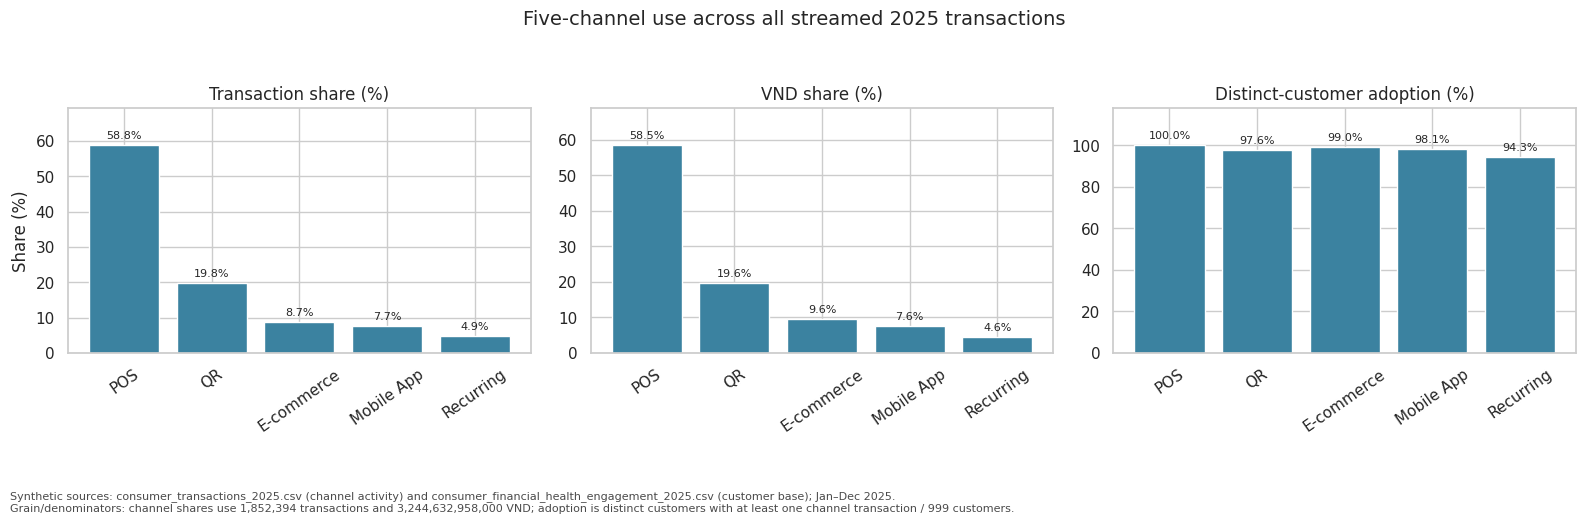

Saved: /home/pearspringmind/Studying/BI-UEL/image/task3/02_channel_breakdown.png


In [7]:
figure, axes = plt.subplots(1, 3, figsize=(16, 5.2), sharex=True)
channel_labels = ["POS", "QR", "E-commerce", "Mobile App", "Recurring"]
channel_metrics = [
    ("transaction_share_pct", "Transaction share (%)"),
    ("vnd_share_pct", "VND share (%)"),
    ("adoption_share_pct", "Distinct-customer adoption (%)"),
]
for axis, (metric, title) in zip(axes, channel_metrics):
    bars = axis.bar(channel_labels, channel_table[metric], color="#3b82a0")
    axis.bar_label(bars, labels=[f"{value:.1f}%" for value in channel_table[metric]], padding=3, fontsize=8)
    axis.set_title(title)
    axis.tick_params(axis="x", rotation=35)
    axis.set_ylim(0, max(5, channel_table[metric].max() * 1.18))
axes[0].set_ylabel("Share (%)")
figure.suptitle("Five-channel use across all streamed 2025 transactions", fontsize=14)
channel_breakdown_path = save_show_close(
    figure,
    "02_channel_breakdown.png",
    "Synthetic sources: consumer_transactions_2025.csv (channel activity) and "
    "consumer_financial_health_engagement_2025.csv (customer base); Jan–Dec 2025.\n"
    f"Grain/denominators: channel shares use {transaction_row_count:,} transactions and "
    f"{transaction_total_spend_vnd:,} VND; adoption is distinct customers with at least one channel transaction "
    f"/ {total_consumers:,} customers.",
)
print(f"Saved: {channel_breakdown_path}")

**Interpretation.** Each panel answers a different question over the same observed 2025 window: transaction share uses **1,852,394 transactions**, VND share uses total streamed VND, and adoption uses distinct channel users divided by **999 monthly-table consumers**. Adoption rates overlap because one customer can use several channels. The chart deliberately keeps POS, QR Payment, E-commerce, Mobile App, and Recurring Payment separate rather than hiding behavior inside one “digital” total.

## 5. Online-spend share is not digital-channel share

The unweighted average customer-month ratio gives every observed consumer-month equal weight. The aggregate ratio weights high-spend months more heavily. Separately, non-POS channel use is reported as digital behavior; QR Payment remains digital even when the transaction's online flag is zero.

In [8]:
monthly_total_spend_vnd = int(monthly["total_spend_vnd"].sum())
if monthly_total_spend_vnd <= 0:
    raise ValueError("Aggregate total_spend_vnd must be positive to calculate online-spend share.")
average_customer_month_online_share = float(monthly["online_spend_ratio"].mean())
aggregate_online_vnd_share = float(monthly["online_spend_vnd"].sum() / monthly_total_spend_vnd)
digital_transaction_count = int(channel_transaction_counts.drop(index="POS").sum())
digital_transaction_spend_vnd = int(channel_spend_vnd.drop(index="POS").sum())

online_share_table = pd.DataFrame({
    "measure": ["Average customer-month online_spend_ratio", "Aggregate online_spend_vnd / total_spend_vnd"],
    "share_pct": [100 * average_customer_month_online_share, 100 * aggregate_online_vnd_share],
    "denominator": [f"{len(monthly):,} customer-months", f"{monthly_total_spend_vnd:,} VND"],
})
digital_online_comparison = pd.DataFrame({
    "measure": [
        "Non-POS digital transactions", "Online-flag transactions",
        "Non-POS digital VND", "Online-flag VND",
        "Non-POS digital adopters", "Online-flag adopters",
        "QR transactions with online flag = 0",
    ],
    "value": [
        digital_transaction_count, online_transaction_count,
        digital_transaction_spend_vnd, online_transaction_spend_vnd,
        len(digital_consumer_ids), len(online_consumer_ids), qr_offline_transaction_count,
    ],
    "share_pct": [
        100 * digital_transaction_count / transaction_row_count,
        100 * online_transaction_count / transaction_row_count,
        100 * digital_transaction_spend_vnd / transaction_total_spend_vnd,
        100 * online_transaction_spend_vnd / transaction_total_spend_vnd,
        100 * len(digital_consumer_ids) / total_consumers,
        100 * len(online_consumer_ids) / total_consumers,
        100 * qr_offline_transaction_count / channel_transaction_counts["QR Payment"],
    ],
})
online_share_display = online_share_table.copy()
online_share_display["share_pct"] = online_share_display["share_pct"].round(2)
digital_online_display = digital_online_comparison.copy()
digital_online_display["share_pct"] = digital_online_display["share_pct"].round(2)
display(online_share_display)
display(digital_online_display)

,measure,share_pct,denominator
0,Average customer-month online_spend_ratio,21.03,"10,992 customer-months"
1,Aggregate online_spend_vnd / total_spend_vnd,21.84,"3,244,632,958,000 VND"


,measure,value,share_pct
0,Non-POS digital transactions,762876,41.18
1,Online-flag transactions,395194,21.33
2,Non-POS digital VND,1345284671000,41.46
3,Online-flag VND,708519089000,21.84
4,Non-POS digital adopters,999,100.00
5,Online-flag adopters,996,99.70
6,QR transactions with online flag = 0,367682,100.00


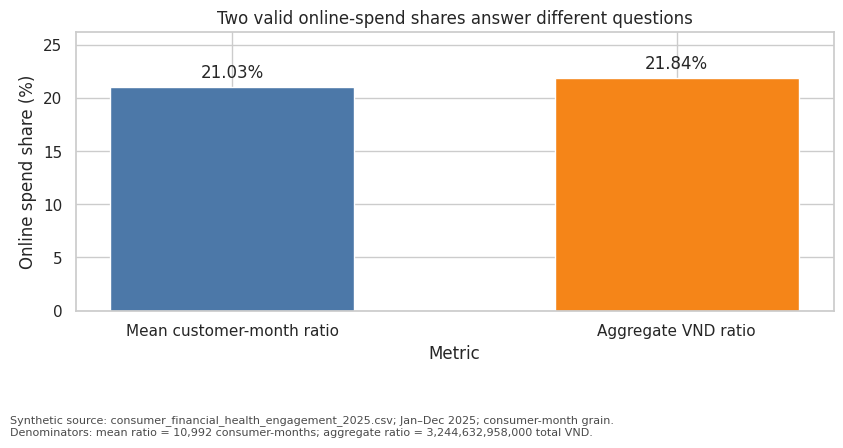

Saved: /home/pearspringmind/Studying/BI-UEL/image/task3/03_online_spend_share.png


In [9]:
figure, axis = plt.subplots(figsize=(8.5, 4.8))
online_labels = ["Mean customer-month ratio", "Aggregate VND ratio"]
online_values = online_share_table["share_pct"]
bars = axis.bar(online_labels, online_values, color=["#4c78a8", "#f58518"], width=0.55)
axis.bar_label(bars, labels=[f"{value:.2f}%" for value in online_values], padding=4)
axis.set(title="Two valid online-spend shares answer different questions", ylabel="Online spend share (%)", xlabel="Metric")
axis.set_ylim(0, max(5, online_values.max() * 1.2))
online_share_path = save_show_close(
    figure,
    "03_online_spend_share.png",
    "Synthetic source: consumer_financial_health_engagement_2025.csv; Jan–Dec 2025; consumer-month grain.\n"
    f"Denominators: mean ratio = {len(monthly):,} consumer-months; "
    f"aggregate ratio = {monthly_total_spend_vnd:,} total VND.",
)
print(f"Saved: {online_share_path}")

**Interpretation.** The first bar is the unweighted mean of `online_spend_ratio` across **10,992 customer-months**; the second is total online VND divided by total VND, so large-spend months receive more weight. Their difference is expected and should not be “reconciled” by replacing one definition with the other. The table above separately shows non-POS digital and online-flag measures. In particular, QR transactions with `online_transaction_flag = 0` demonstrate why QR/digital must not be treated as synonymous with online.

## 6. Category diversity and engagement

Category diversity is a discrete count of distinct spending categories in a consumer-month. Counts, medians, and interquartile ranges show the relationship without implying that diversity independently causes engagement.

In [10]:
diversity_summary = (
    monthly.groupby("category_diversity")["engagement_score"]
    .agg(
        customer_months="size",
        mean_engagement="mean",
        median_engagement="median",
        q25=lambda values: values.quantile(0.25),
        q75=lambda values: values.quantile(0.75),
    )
    .reset_index()
)
diversity_ceiling = int(monthly["category_diversity"].max())
diversity_ceiling_count = int(monthly["category_diversity"].eq(diversity_ceiling).sum())
display(diversity_summary.round(2))
print(
    f"Observed diversity range: {monthly['category_diversity'].min()}–{diversity_ceiling} categories; "
    f"ceiling mass: {diversity_ceiling_count:,}/{len(monthly):,} "
    f"({100 * diversity_ceiling_count / len(monthly):.2f}%)."
)

,category_diversity,customer_months,mean_engagement,median_engagement,q25,q75
0,2,3,23.30,12.80,11.25,30.10
1,3,9,40.72,45.30,43.10,51.30
2,4,19,50.53,50.90,46.60,54.30
3,5,40,49.41,48.85,47.40,54.42
4,6,18,50.27,51.60,49.22,55.30
5,7,7,52.06,51.10,47.35,56.15
6,9,1,61.90,61.90,61.90,61.90
7,10,19,64.26,63.20,58.40,67.55
8,11,82,69.37,68.05,63.62,72.85
9,12,387,70.03,69.00,65.65,74.00


Observed diversity range: 2–14 categories; ceiling mass: 8,667/10,992 (78.85%).


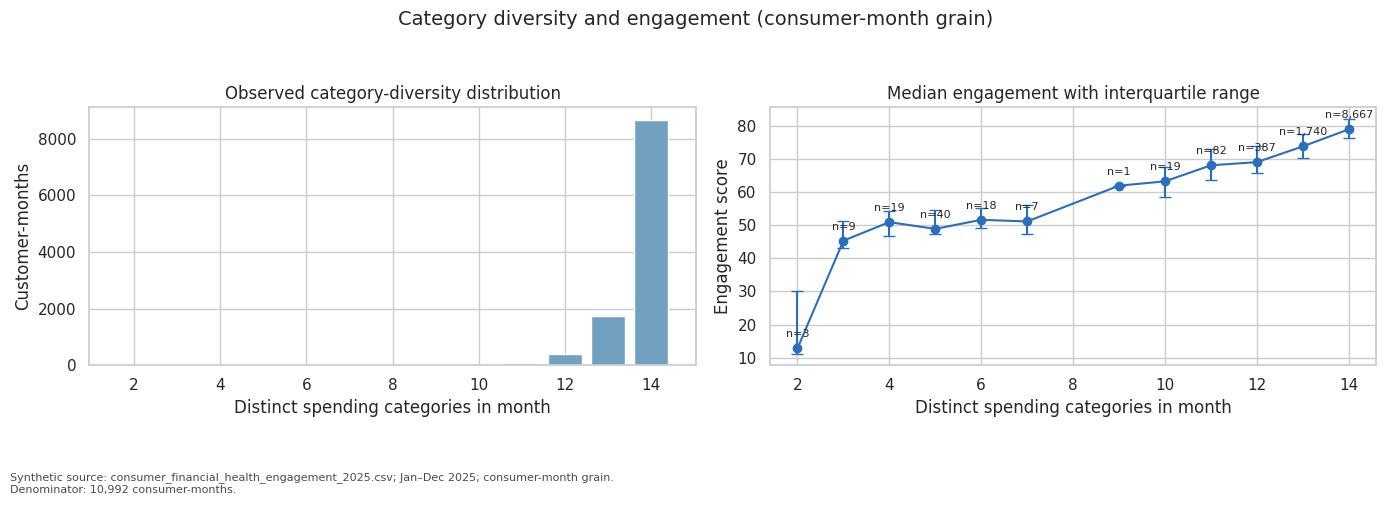

Saved: /home/pearspringmind/Studying/BI-UEL/image/task3/04_category_diversity_engagement.png


In [11]:
figure, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].bar(diversity_summary["category_diversity"], diversity_summary["customer_months"], color="#72a0c1")
axes[0].set(title="Observed category-diversity distribution", xlabel="Distinct spending categories in month", ylabel="Customer-months")

lower_error = diversity_summary["median_engagement"] - diversity_summary["q25"]
upper_error = diversity_summary["q75"] - diversity_summary["median_engagement"]
axes[1].errorbar(
    diversity_summary["category_diversity"],
    diversity_summary["median_engagement"],
    yerr=np.vstack([lower_error, upper_error]),
    fmt="o-", capsize=4, color="#2a6fbb",
)
for row in diversity_summary.itertuples(index=False):
    axes[1].annotate(f"n={row.customer_months:,}", (row.category_diversity, row.median_engagement), xytext=(0, 8), textcoords="offset points", ha="center", fontsize=8)
axes[1].set(title="Median engagement with interquartile range", xlabel="Distinct spending categories in month", ylabel="Engagement score")
figure.suptitle("Category diversity and engagement (consumer-month grain)", fontsize=14)
diversity_path = save_show_close(
    figure,
    "04_category_diversity_engagement.png",
    "Synthetic source: consumer_financial_health_engagement_2025.csv; Jan–Dec 2025; consumer-month grain.\n"
    f"Denominator: {len(monthly):,} consumer-months.",
)
print(f"Saved: {diversity_path}")

**Interpretation.** The left panel reports the complete observed diversity range and makes any mass at the maximum visible. The right panel compares median engagement at each discrete diversity value; whiskers are the 25th–75th percentile range and every point names its customer-month **n**. Unequal group sizes and a ceiling at the maximum category count limit inference. This is an association in synthetic consumer-month data, not an independent or causal effect.

## 7. Transaction frequency and engagement

Frequency is monthly transaction count. Quantile-derived bins preserve the observed range while avoiding a dense raw scatter; bin limits and sample sizes remain visible.

In [12]:
frequency_edges = np.unique(
    monthly["transaction_count"].quantile([0, 0.2, 0.4, 0.6, 0.8, 1]).to_numpy()
)
if len(frequency_edges) < 3:
    raise ValueError("Transaction frequency has too little variation for a binned relationship view.")
frequency_bin_ids = pd.cut(
    monthly["transaction_count"],
    bins=frequency_edges,
    labels=False,
    include_lowest=True,
    duplicates="drop",
)
if frequency_bin_ids.isna().any():
    raise ValueError("Frequency binning did not cover every customer-month.")
monthly["frequency_bin_id"] = frequency_bin_ids.astype("int64")
frequency_summary = (
    monthly.groupby("frequency_bin_id", sort=True)["engagement_score"]
    .agg(
        customer_months="size",
        frequency_min=lambda values: monthly.loc[values.index, "transaction_count"].min(),
        frequency_max=lambda values: monthly.loc[values.index, "transaction_count"].max(),
        median_engagement="median",
        q25=lambda values: values.quantile(0.25),
        q75=lambda values: values.quantile(0.75),
    )
    .reset_index()
)
frequency_summary["bin_label"] = frequency_summary.apply(
    lambda row: f"{int(row['frequency_min'])}–{int(row['frequency_max'])}", axis=1
)
display(frequency_summary.drop(columns="frequency_bin_id").round(2))

,customer_months,frequency_min,frequency_max,median_engagement,q25,q75,bin_label
0,2242,2,70,71.8,68.0,76.57,2–70
1,2202,71,121,76.2,73.5,79.90,71–121
2,2184,122,176,78.3,75.9,81.40,122–176
3,2166,177,242,79.5,77.4,82.10,177–242
4,2198,243,713,80.4,78.2,82.80,243–713


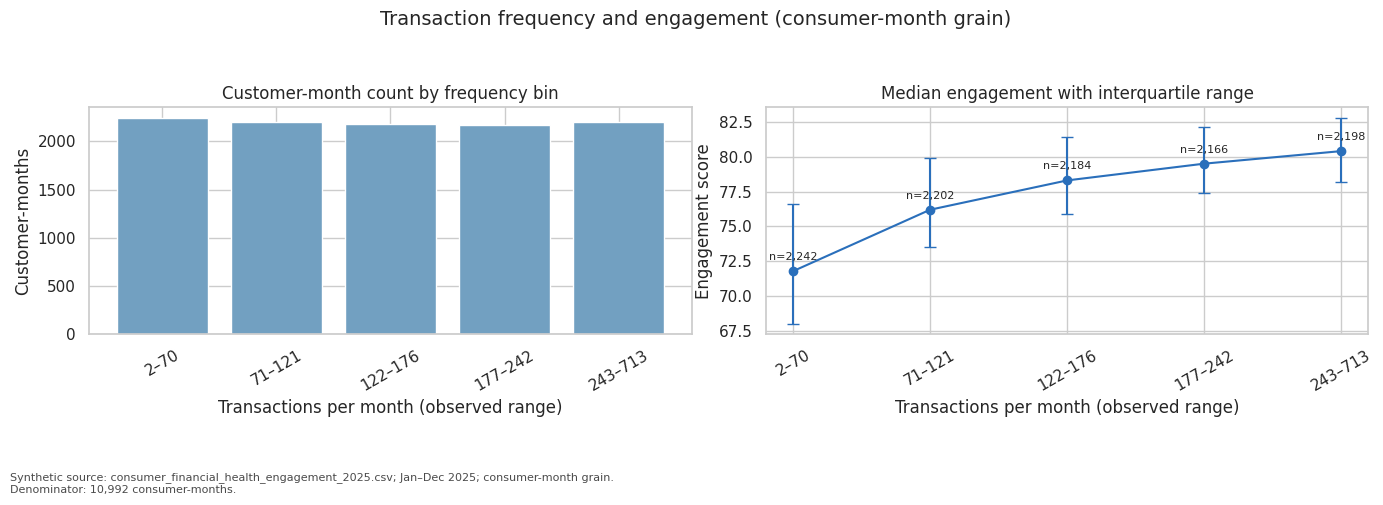

Saved: /home/pearspringmind/Studying/BI-UEL/image/task3/05_frequency_engagement.png


In [13]:
figure, axes = plt.subplots(1, 2, figsize=(14, 5))
frequency_positions = np.arange(len(frequency_summary))
axes[0].bar(frequency_positions, frequency_summary["customer_months"], color="#72a0c1")
axes[0].set_xticks(frequency_positions, frequency_summary["bin_label"], rotation=30)
axes[0].set(title="Customer-month count by frequency bin", xlabel="Transactions per month (observed range)", ylabel="Customer-months")

frequency_lower_error = frequency_summary["median_engagement"] - frequency_summary["q25"]
frequency_upper_error = frequency_summary["q75"] - frequency_summary["median_engagement"]
axes[1].errorbar(
    frequency_positions, frequency_summary["median_engagement"],
    yerr=np.vstack([frequency_lower_error, frequency_upper_error]),
    fmt="o-", capsize=4, color="#2a6fbb",
)
axes[1].set_xticks(frequency_positions, frequency_summary["bin_label"], rotation=30)
for position, row in enumerate(frequency_summary.itertuples(index=False)):
    axes[1].annotate(f"n={row.customer_months:,}", (position, row.median_engagement), xytext=(0, 8), textcoords="offset points", ha="center", fontsize=8)
axes[1].set(title="Median engagement with interquartile range", xlabel="Transactions per month (observed range)", ylabel="Engagement score")
figure.suptitle("Transaction frequency and engagement (consumer-month grain)", fontsize=14)
frequency_path = save_show_close(
    figure,
    "05_frequency_engagement.png",
    "Synthetic source: consumer_financial_health_engagement_2025.csv; Jan–Dec 2025; consumer-month grain.\n"
    f"Denominator: {len(monthly):,} consumer-months.",
)
print(f"Saved: {frequency_path}")

**Interpretation.** The left panel shows how the **10,992 customer-months** occupy the displayed transaction-count ranges. The right panel compares median engagement across those ranges, with interquartile whiskers and explicit **n**. Quantile-derived bins describe the dataset rather than impose a business threshold. Any upward pattern is descriptive and partly mechanical because transaction frequency is related to the constructed engagement score; it is not a causal estimate.

## 8. Transaction recency and engagement

Recency is days from the last transaction to month end. Explicit bins isolate day zero so its potentially dominant mass is not hidden inside a wider interval.

In [14]:
recency_labels = ["0", "1", "2–3", "4–7", "8–14", "15+"]
monthly["recency_bin"] = pd.cut(
    monthly["transaction_recency_days"],
    bins=[-0.5, 0.5, 1.5, 3.5, 7.5, 14.5, np.inf],
    labels=recency_labels,
    right=False,
)
if monthly["recency_bin"].isna().any():
    raise ValueError("Recency binning did not cover every customer-month.")
recency_summary = (
    monthly.groupby("recency_bin", observed=False)["engagement_score"]
    .agg(
        customer_months="size",
        median_engagement="median",
        q25=lambda values: values.quantile(0.25),
        q75=lambda values: values.quantile(0.75),
    )
    .reindex(recency_labels)
    .reset_index()
)
recency_summary["customer_month_share_pct"] = 100 * recency_summary["customer_months"] / len(monthly)
display(recency_summary.round(2))
zero_recency_count = int(monthly["transaction_recency_days"].eq(0).sum())
print(
    f"Observed recency range: {monthly['transaction_recency_days'].min()}–{monthly['transaction_recency_days'].max()} days; "
    f"zero-day mass: {zero_recency_count:,}/{len(monthly):,} customer-months "
    f"({100 * zero_recency_count / len(monthly):.2f}%)."
)

,recency_bin,customer_months,median_engagement,q25,q75,customer_month_share_pct
0,0,10435,78.30,75.20,81.50,94.93
1,1,399,72.50,68.25,77.05,3.63
2,2–3,82,69.75,64.53,75.07,0.75
3,4–7,17,53.90,51.30,55.00,0.15
4,8–14,11,52.90,51.25,54.60,0.10
5,15+,48,46.80,43.08,48.82,0.44


Observed recency range: 0–30 days; zero-day mass: 10,435/10,992 customer-months (94.93%).


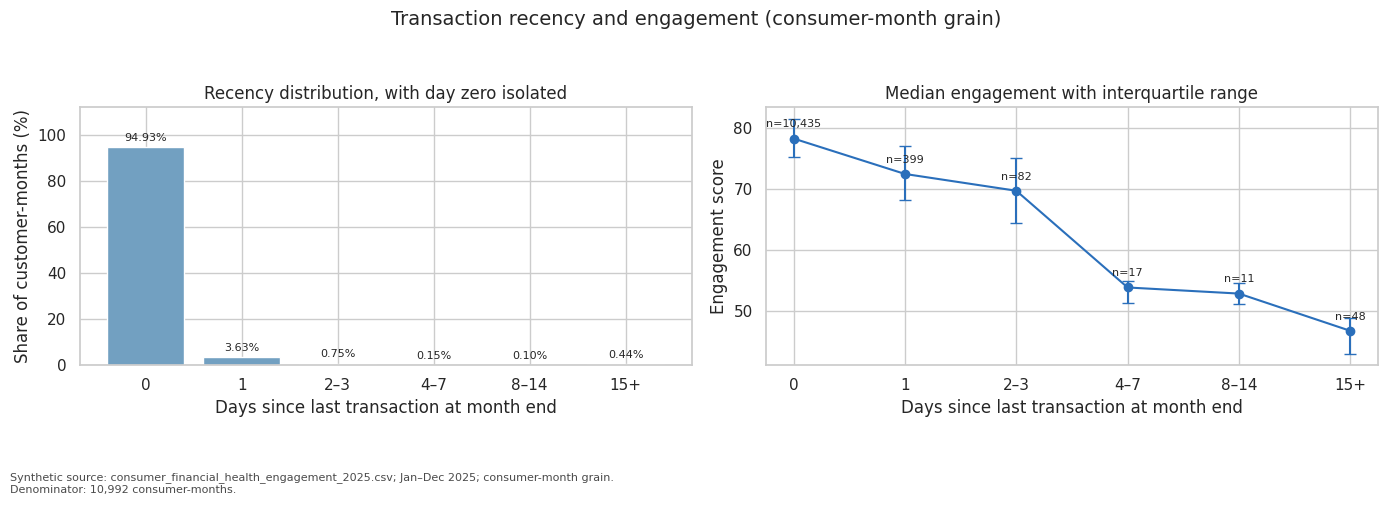

Saved: /home/pearspringmind/Studying/BI-UEL/image/task3/06_recency_engagement.png


In [15]:
figure, axes = plt.subplots(1, 2, figsize=(14, 5))
recency_positions = np.arange(len(recency_summary))
share_bars = axes[0].bar(recency_positions, recency_summary["customer_month_share_pct"], color="#72a0c1")
axes[0].bar_label(share_bars, labels=[f"{value:.2f}%" for value in recency_summary["customer_month_share_pct"]], padding=3, fontsize=8)
axes[0].set_xticks(recency_positions, recency_summary["recency_bin"])
axes[0].set(title="Recency distribution, with day zero isolated", xlabel="Days since last transaction at month end", ylabel="Share of customer-months (%)")
axes[0].set_ylim(0, max(5, recency_summary["customer_month_share_pct"].max() * 1.18))

observed_recency = recency_summary[recency_summary["customer_months"].gt(0)].copy()
observed_positions = np.arange(len(observed_recency))
recency_lower_error = observed_recency["median_engagement"] - observed_recency["q25"]
recency_upper_error = observed_recency["q75"] - observed_recency["median_engagement"]
axes[1].errorbar(
    observed_positions, observed_recency["median_engagement"],
    yerr=np.vstack([recency_lower_error, recency_upper_error]),
    fmt="o-", capsize=4, color="#2a6fbb",
)
axes[1].set_xticks(observed_positions, observed_recency["recency_bin"])
for position, row in enumerate(observed_recency.itertuples(index=False)):
    axes[1].annotate(f"n={row.customer_months:,}", (position, row.median_engagement), xytext=(0, 8), textcoords="offset points", ha="center", fontsize=8)
axes[1].set(title="Median engagement with interquartile range", xlabel="Days since last transaction at month end", ylabel="Engagement score")
figure.suptitle("Transaction recency and engagement (consumer-month grain)", fontsize=14)
recency_path = save_show_close(
    figure,
    "06_recency_engagement.png",
    "Synthetic source: consumer_financial_health_engagement_2025.csv; Jan–Dec 2025; consumer-month grain.\n"
    f"Denominator: {len(monthly):,} consumer-months.",
)
print(f"Saved: {recency_path}")

**Interpretation.** The first panel explicitly separates the **zero-day recency mass** from longer intervals, using all 10,992 customer-months. The second compares median engagement only for observed bins and prints each bin's **n**; whiskers are interquartile ranges. Small nonzero-recency groups should not be given the same evidential weight as the dominant zero-day group. The relationship is descriptive and may be partly embedded in the engagement-score construction.

## 9. Healthy but less engaged: cutoff sensitivity and observed history

Financially healthy is fixed at `financial_health_score >= 80`. Three engagement cutoffs are compared:

- **Strict `<40`**: only the official Low band; precise but can miss Medium engagement.
- **Primary `<60`**: the official Low and Medium bands, so “less engaged” means not in either High band without redefining the source segments.
- **Loose `<70`**: a sensitivity bound that includes scores from 60–69 inside the official High band; useful for scale comparison, but too loose as the primary definition.

The primary result therefore uses health `>=80` and engagement `<60`. Counts represent observed history, not confirmed current status or churn risk.

In [16]:
healthy_mask = monthly["financial_health_score"].ge(80)
healthy_customer_months = int(healthy_mask.sum())
cutoff_definitions = [
    ("Strict: engagement <40", 40),
    ("Primary: engagement <60", 60),
    ("Loose: engagement <70", 70),
]
december_month = pd.Timestamp("2025-12-01")
december_mask = monthly["analysis_month"].eq(december_month)
december_observed_customers = monthly.loc[december_mask, "consumer_id"].nunique()

sensitivity_rows = []
monthly_count_frames = []
all_observed_months = pd.date_range("2025-01-01", "2025-12-01", freq="MS")
for cutoff_label, cutoff_value in cutoff_definitions:
    crossover_mask = healthy_mask & monthly["engagement_score"].lt(cutoff_value)
    crossover_rows = monthly.loc[crossover_mask]
    sensitivity_rows.append({
        "definition": cutoff_label,
        "engagement_cutoff": cutoff_value,
        "customer_months": int(crossover_mask.sum()),
        "share_all_customer_months_pct": 100 * crossover_mask.mean(),
        "share_healthy_customer_months_pct": (
            100 * crossover_mask.sum() / healthy_customer_months if healthy_customer_months else np.nan
        ),
        "distinct_2025_customers": crossover_rows["consumer_id"].nunique(),
        "share_all_customers_pct": 100 * crossover_rows["consumer_id"].nunique() / total_consumers,
        "december_customer_months": int((crossover_mask & december_mask).sum()),
        "december_distinct_customers": monthly.loc[crossover_mask & december_mask, "consumer_id"].nunique(),
    })
    month_counts = (
        monthly.loc[crossover_mask].groupby("analysis_month").size().reindex(all_observed_months, fill_value=0)
    )
    monthly_count_frames.append(
        month_counts.rename(cutoff_label).rename_axis("analysis_month")
    )

crossover_sensitivity = pd.DataFrame(sensitivity_rows).set_index("definition")
monthly_crossover_counts = pd.concat(monthly_count_frames, axis=1).astype(int)
sensitivity_display = crossover_sensitivity.copy()
percentage_columns = [
    "share_all_customer_months_pct", "share_healthy_customer_months_pct", "share_all_customers_pct",
]
sensitivity_display[percentage_columns] = sensitivity_display[percentage_columns].round(2)
display(sensitivity_display)
display(monthly_crossover_counts)
print(
    f"December 2025 observed population: {december_observed_customers:,} distinct customers; "
    f"healthy customer-months in December: {int((healthy_mask & december_mask).sum()):,}."
)

,engagement_cutoff,customer_months,share_all_customer_months_pct,share_healthy_customer_months_pct,distinct_2025_customers,share_all_customers_pct,december_customer_months,december_distinct_customers
definition,,,,,,,,
Strict: engagement <40,40,1,0.01,0.21,1,0.10,0,0
Primary: engagement <60,60,6,0.05,1.26,6,0.60,0,0
Loose: engagement <70,70,135,1.23,28.42,94,9.41,0,0


,Strict: engagement <40,Primary: engagement <60,Loose: engagement <70
analysis_month,,,
2025-01-01,0,3,37
2025-02-01,1,3,48
2025-03-01,0,0,11
2025-04-01,0,0,10
2025-05-01,0,0,5
2025-06-01,0,0,1
2025-07-01,0,0,0
2025-08-01,0,0,1
2025-09-01,0,0,10


December 2025 observed population: 918 distinct customers; healthy customer-months in December: 0.


In [17]:
primary_mask = healthy_mask & monthly["engagement_score"].lt(60)
observed_history = (
    monthly.groupby("consumer_id")
    .agg(
        n_observed_months=("analysis_month", "size"),
        first_observed_month=("analysis_month", "min"),
        last_observed_month=("analysis_month", "max"),
    )
)
primary_history = (
    monthly.loc[primary_mask]
    .groupby("consumer_id")
    .agg(
        n_crossover_months=("analysis_month", "size"),
        first_crossover_month=("analysis_month", "min"),
        last_crossover_month=("analysis_month", "max"),
        mean_health_score_in_crossover=("financial_health_score", "mean"),
        mean_engagement_score_in_crossover=("engagement_score", "mean"),
        mean_transactions_in_crossover=("transaction_count", "mean"),
        mean_online_spend_ratio_in_crossover=("online_spend_ratio", "mean"),
        mean_category_diversity_in_crossover=("category_diversity", "mean"),
        mean_recency_days_in_crossover=("transaction_recency_days", "mean"),
    )
)
last_observed_profile = (
    monthly.sort_values(["consumer_id", "analysis_month"])
    .groupby("consumer_id", as_index=False)
    .tail(1)
    .set_index("consumer_id")[["analysis_month", "age", "gender", "occupation", "province_city", "monthly_income_vnd"]]
    .rename(columns={"analysis_month": "last_observed_profile_month"})
)
primary_customer_profile = (
    primary_history.join(observed_history, how="left")
    .join(last_observed_profile, how="left")
    .sort_values(["n_crossover_months", "mean_engagement_score_in_crossover"], ascending=[False, True])
)
profile_numeric_columns = [
    "n_observed_months", "n_crossover_months", "mean_health_score_in_crossover",
    "mean_engagement_score_in_crossover", "mean_transactions_in_crossover",
    "mean_online_spend_ratio_in_crossover", "mean_category_diversity_in_crossover",
    "mean_recency_days_in_crossover", "age", "monthly_income_vnd",
]
profile_numeric_summary = primary_customer_profile[profile_numeric_columns].agg(["count", "mean", "median", "min", "max"]).T
display(profile_numeric_summary.round(2))
display(primary_customer_profile.head(20).round(3))
if len(primary_customer_profile) > 20:
    print(f"Showing 20 of {len(primary_customer_profile):,} distinct primary-crossover customers.")

if primary_customer_profile.empty:
    print("No customers meet the primary crossover definition; demographic profile tables are empty.")
else:
    for profile_dimension in ["gender", "occupation", "province_city"]:
        dimension_table = (
            primary_customer_profile[profile_dimension].value_counts().rename("distinct_customers").to_frame()
        )
        dimension_table["group_share_pct"] = 100 * dimension_table["distinct_customers"] / len(primary_customer_profile)
        display(Markdown(f"**Primary-crossover profile by {profile_dimension.replace('_', ' ')} (top 10)**"))
        display(dimension_table.head(10).round(2))

,count,mean,median,min,max
n_observed_months,6.0,1.033000e+01,1.200000e+01,2.0,1.200000e+01
n_crossover_months,6.0,1.000000e+00,1.000000e+00,1.0,1.000000e+00
mean_health_score_in_crossover,6.0,8.545000e+01,8.580000e+01,82.0,8.830000e+01
mean_engagement_score_in_crossover,6.0,5.108000e+01,5.850000e+01,12.3,5.990000e+01
mean_transactions_in_crossover,6.0,2.717000e+01,3.100000e+01,3.0,3.500000e+01
mean_online_spend_ratio_in_crossover,6.0,5.000000e-02,3.000000e-02,0.0,1.200000e-01
mean_category_diversity_in_crossover,6.0,9.670000e+00,1.050000e+01,3.0,1.200000e+01
mean_recency_days_in_crossover,6.0,5.170000e+00,1.000000e+00,0.0,2.700000e+01
age,6.0,5.550000e+01,5.250000e+01,50.0,7.500000e+01
monthly_income_vnd,6.0,1.598317e+08,1.716750e+08,60880000.0,2.329400e+08


,n_crossover_months,first_crossover_month,last_crossover_month,mean_health_score_in_crossover,mean_engagement_score_in_crossover,mean_transactions_in_crossover,mean_online_spend_ratio_in_crossover,mean_category_diversity_in_crossover,mean_recency_days_in_crossover,n_observed_months,first_observed_month,last_observed_month,last_observed_profile_month,age,gender,occupation,province_city,monthly_income_vnd
consumer_id,,,,,,,,,,,,,,,,,,
KH00114725,1,2025-02-01,2025-02-01,88.3,12.3,3.0,0.000,3.0,27.0,2,2025-01-01,2025-02-01,2025-02-01,50,Nam,Chuyên viên di truyền tế bào lâm sàng,Thành phố Hồ Chí Minh,60880000
KH00105725,1,2025-01-01,2025-01-01,86.3,57.5,35.0,0.017,11.0,0.0,12,2025-01-01,2025-12-01,2025-12-01,53,Nam,Luật sư sáng chế,Nghệ An,186340000
KH00112770,1,2025-02-01,2025-02-01,82.0,58.4,30.0,0.009,12.0,0.0,12,2025-01-01,2025-12-01,2025-12-01,75,Nữ,Nhà địa chất thủy văn,Đồng Nai,124620000
KH00119485,1,2025-02-01,2025-02-01,86.2,58.6,29.0,0.051,10.0,0.0,12,2025-01-01,2025-12-01,2025-12-01,52,Nam,Bác sĩ đo mắt,Đồng Tháp,232940000
KH00107005,1,2025-01-01,2025-01-01,85.4,59.8,34.0,0.075,12.0,2.0,12,2025-01-01,2025-12-01,2025-12-01,53,Nam,Kỹ sư vật liệu,Tuyên Quang,197200000
KH00108245,1,2025-01-01,2025-01-01,84.5,59.9,32.0,0.119,10.0,2.0,12,2025-01-01,2025-12-01,2025-12-01,50,Nam,Chuyên viên biên tập nội dung,Thành phố Hồ Chí Minh,157010000


**Primary-crossover profile by gender (top 10)**

,distinct_customers,group_share_pct
gender,,
Nam,5,83.33
Nữ,1,16.67


**Primary-crossover profile by occupation (top 10)**

,distinct_customers,group_share_pct
occupation,,
Chuyên viên di truyền tế bào lâm sàng,1,16.67
Luật sư sáng chế,1,16.67
Nhà địa chất thủy văn,1,16.67
Bác sĩ đo mắt,1,16.67
Kỹ sư vật liệu,1,16.67
Chuyên viên biên tập nội dung,1,16.67


**Primary-crossover profile by province city (top 10)**

,distinct_customers,group_share_pct
province_city,,
Thành phố Hồ Chí Minh,2,33.33
Nghệ An,1,16.67
Đồng Nai,1,16.67
Đồng Tháp,1,16.67
Tuyên Quang,1,16.67


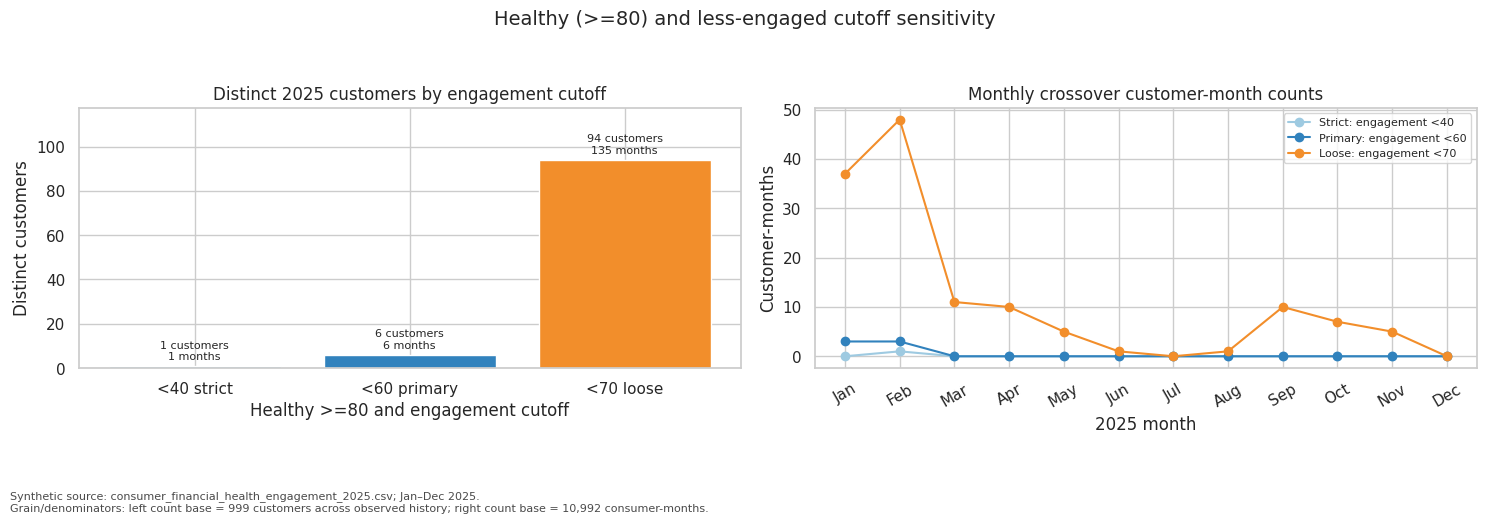

Saved: /home/pearspringmind/Studying/BI-UEL/image/task3/07_healthy_low_engagement_sensitivity.png


In [18]:
figure, axes = plt.subplots(1, 2, figsize=(15, 5.2))
sensitivity_positions = np.arange(len(crossover_sensitivity))
sensitivity_bars = axes[0].bar(
    sensitivity_positions, crossover_sensitivity["distinct_2025_customers"],
    color=["#9ecae1", "#3182bd", "#f28e2b"],
)
axes[0].bar_label(
    sensitivity_bars,
    labels=[
        f"{customers:,} customers\n{months:,} months"
        for customers, months in zip(
            crossover_sensitivity["distinct_2025_customers"],
            crossover_sensitivity["customer_months"],
        )
    ],
    padding=3, fontsize=8,
)
axes[0].set_xticks(sensitivity_positions, ["<40 strict", "<60 primary", "<70 loose"])
axes[0].set(title="Distinct 2025 customers by engagement cutoff", ylabel="Distinct customers", xlabel="Healthy >=80 and engagement cutoff")
axes[0].set_ylim(0, max(1, crossover_sensitivity["distinct_2025_customers"].max() * 1.25))

month_labels = monthly_crossover_counts.index.strftime("%b")
for definition, color in zip(monthly_crossover_counts.columns, ["#9ecae1", "#3182bd", "#f28e2b"]):
    axes[1].plot(month_labels, monthly_crossover_counts[definition], marker="o", label=definition, color=color)
axes[1].set(title="Monthly crossover customer-month counts", ylabel="Customer-months", xlabel="2025 month")
axes[1].legend(fontsize=8)
axes[1].tick_params(axis="x", rotation=30)
figure.suptitle("Healthy (>=80) and less-engaged cutoff sensitivity", fontsize=14)
crossover_path = save_show_close(
    figure,
    "07_healthy_low_engagement_sensitivity.png",
    "Synthetic source: consumer_financial_health_engagement_2025.csv; Jan–Dec 2025.\n"
    f"Grain/denominators: left count base = {total_consumers:,} customers across observed history; "
    f"right count base = {len(monthly):,} consumer-months.",
)
print(f"Saved: {crossover_path}")

**Interpretation.** The left panel shows distinct consumers with at least one matching month anywhere in observed 2025 history; labels also report matching customer-months. The right panel shows the month-by-month row counts, including explicit zeros. The `<60` primary cutoff follows the source bands by combining Low and Medium; `<40` is a stricter lower bound, while `<70` deliberately intrudes into the official High band and is only a looser sensitivity case. December is separately reported against its observed-customer snapshot—even when zero—and never used to silently relax the health threshold. These historical synthetic cases are not evidence that anyone is currently disengaged, contactable, leaving, or likely to churn.

## 10. Executive takeaways

In [19]:
largest_band = engagement_band_table["customer_months"].idxmax()
largest_channel_by_count = channel_table["transaction_count"].idxmax()
primary_result = crossover_sensitivity.loc["Primary: engagement <60"]
executive_text = f"""
- **Engagement distribution:** {largest_band} is the largest official band at {engagement_band_table.loc[largest_band, 'customer_month_share_pct']:.2f}% of customer-months. Treat upper-end concentration as score compression, not retention or wellbeing.
- **Channels:** {largest_channel_by_count} has the largest transaction count share ({channel_table.loc[largest_channel_by_count, 'transaction_share_pct']:.2f}%). The five-channel table separately reports count, VND, and distinct-customer adoption.
- **Online spend:** the mean customer-month online share is {100 * average_customer_month_online_share:.2f}%, while the aggregate VND share is {100 * aggregate_online_vnd_share:.2f}%; these differ because their weighting differs. QR/digital remains distinct from the online flag.
- **Behavioral relationships:** category diversity, frequency, and recency are shown with ranges, sample sizes, medians, and interquartile ranges. They are descriptive and may be components of the constructed engagement score.
- **Primary crossover:** health >=80 and engagement <60 identifies {int(primary_result['customer_months']):,} customer-months and {int(primary_result['distinct_2025_customers']):,} distinct consumers across observed 2025 history. December contains {int(primary_result['december_distinct_customers']):,} matching observed consumers out of {december_observed_customers:,}; zero is retained when observed. This is not a churn, contactability, or credit-decision label.
"""
display(Markdown(executive_text))


- **Engagement distribution:** High is the largest official band at 64.21% of customer-months. Treat upper-end concentration as score compression, not retention or wellbeing.
- **Channels:** POS has the largest transaction count share (58.82%). The five-channel table separately reports count, VND, and distinct-customer adoption.
- **Online spend:** the mean customer-month online share is 21.03%, while the aggregate VND share is 21.84%; these differ because their weighting differs. QR/digital remains distinct from the online flag.
- **Behavioral relationships:** category diversity, frequency, and recency are shown with ranges, sample sizes, medians, and interquartile ranges. They are descriptive and may be components of the constructed engagement score.
- **Primary crossover:** health >=80 and engagement <60 identifies 6 customer-months and 6 distinct consumers across observed 2025 history. December contains 0 matching observed consumers out of 918; zero is retained when observed. This is not a churn, contactability, or credit-decision label.


### Scope and limitations

All identities and financial values are synthetic. Observed histories differ in length, so the crossover profile retains `n_observed_months`, first/last observed months, and crossover-month counts. Results cover only recorded 2025 activity. No chart establishes causality, future behavior, attrition, churn, present-day contactability, or suitability for credit decisions.